In [9]:
s3.ls('tt-bootcamp-shared/titanic.csv')

['tt-bootcamp-shared/titanic.csv']

In [15]:
%%duckdb 

select survived,count(1) from 's3://tt-bootcamp-shared/titanic.csv'  group by 1

,survived,count(1)
0,0,549
1,1,342


In [27]:
%%duckdb  -o cm

select y_true::varchar as y_true, y_pred::varchar as y_pred,count(1) as n from 
(select survived as y_true, 0 as y_pred from 's3://tt-bootcamp-shared/titanic.csv') group by 1,2

,y_true,y_pred,n
0,1,0,342
1,0,0,549


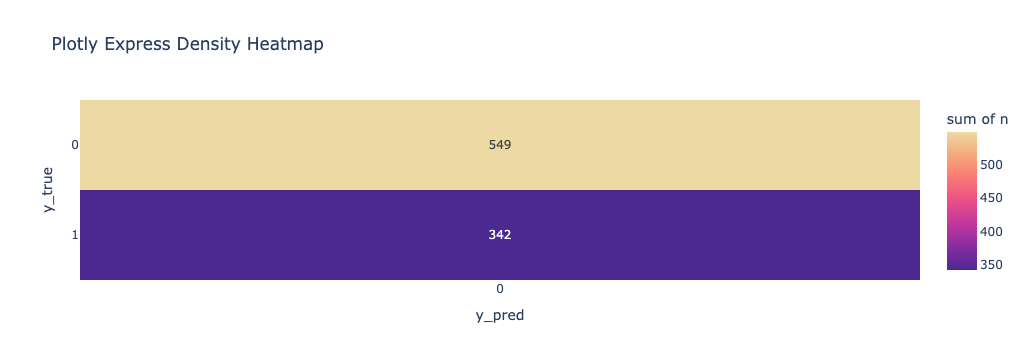

In [29]:
import plotly.express as px

fig = px.density_heatmap(
    cm, 
    x='y_pred', 
    y='y_true', 
    z='n', 
    text_auto=True,  # Shows the numbers inside the blocks
    color_continuous_scale='agsunset',
    title='Plotly Express Density Heatmap'
)
fig

In [33]:
f"My accuracy is {549 / (549+342):.2f}"

'My accuracy is 0.62'

## Proper Experiment Design

In [99]:
%%duckdb -o test_df

select * from 
(select random() rnd, * from 's3://tt-bootcamp-shared/titanic.csv') where rnd < 0.2

,rnd,passenger_id,survived,passenger_class,name,sex,age,siblings_spouses_aboard,parents_children_aboard,ticket_number,fare,embarkation_port
0,0.072157,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
1,0.176409,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,S
2,0.025593,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,S
3,0.101563,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,S
4,0.154644,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.8958,S
...,...,...,...,...,...,...,...,...,...,...,...,...
177,0.132352,866,1,2,"Bystrom, Mrs. (Karolina)",female,42.0,0,0,236852,13.0000,S
178,0.149737,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,S
179,0.153071,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,S
180,0.093454,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C


In [100]:
%%duckdb -o train_df

select * from 's3://tt-bootcamp-shared/titanic.csv' where passenger_id not in (select passenger_id from test_df)

,passenger_id,survived,passenger_class,name,sex,age,siblings_spouses_aboard,parents_children_aboard,ticket_number,fare,embarkation_port
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q
...,...,...,...,...,...,...,...,...,...,...,...
704,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Q
705,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
706,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
707,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [51]:
%%duckdb

select  survived,count(1) from train_df group by 1;

,survived,count(1)
0,0,437
1,1,268


In [48]:
%%duckdb  -o cm

select y_true::varchar as y_true, y_pred::varchar as y_pred,count(1) as n from 
(select survived as y_true, 0 as y_pred from test_df) group by 1,2

,y_true,y_pred,n
0,1,0,74
1,0,0,112


In [50]:
112/(112+74)

0.6021505376344086

In [55]:
%%duckdb -o test_df

create or replace table survival as 
select * from 
(select row_number() over(order by random()) as rn, * from 's3://tt-bootcamp-shared/titanic.csv') 

,Count
0,891


In [65]:
train_fold_0 =  %duckdb select * from survival where rn%5 != 0
test_fold_0 =  %duckdb select * from survival where rn%5 = 0

train_fold_1 =  %duckdb select * from survival where rn%5 != 1
test_fold_1 =  %duckdb select * from survival where rn%5 = 1

train_fold_2 =  %duckdb select * from survival where rn%5 != 2
test_fold_2 =  %duckdb select * from survival where rn%5 = 2

train_fold_3 =  %duckdb select * from survival where rn%5 != 3
test_fold_3 =  %duckdb select * from survival where rn%5 = 3

train_fold_4 =  %duckdb select * from survival where rn%5 != 4
test_fold_4 =  %duckdb select * from survival where rn%5 = 4

In [70]:
 %%duckdb

select  survived,count(1) from train_fold_4 group by 1;

,survived,count(1)
0,0,445
1,1,268


In [82]:
%%duckdb 

select sum(case when y_pred = y_true then n end)/sum(n) acc from 
(select y_true,y_pred,count(1) as n from 
(select survived as y_true, 0 as y_pred from test_fold_0) group by 1,2)

,acc
0,0.634831


In [78]:
%%duckdb 

select sum(case when y_pred = y_true then n end)/sum(n) acc from 
(select y_true,y_pred,count(1) as n from 
(select survived as y_true, 0 as y_pred from test_fold_1) group by 1,2)

,acc
0,0.569832


In [79]:
%%duckdb 

select sum(case when y_pred = y_true then n end)/sum(n) acc from 
(select y_true,y_pred,count(1) as n from 
(select survived as y_true, 0 as y_pred from test_fold_2) group by 1,2)

,acc
0,0.617978


In [80]:
%%duckdb 

select sum(case when y_pred = y_true then n end)/sum(n) acc from 
(select y_true,y_pred,count(1) as n from 
(select survived as y_true, 0 as y_pred from test_fold_3) group by 1,2)

,acc
0,0.674157


In [81]:
%%duckdb 

select sum(case when y_pred = y_true then n end)/sum(n) acc from 
(select y_true,y_pred,count(1) as n from 
(select survived as y_true, 0 as y_pred from test_fold_4) group by 1,2)

,acc
0,0.58427


In [83]:
# x o 0.5 -> 0.25 -> 0.125 -> 0.0625

In [84]:
# x o o 1/3 ....

### Simple Probailistic Model

- $P(y) > 0$
- $P(x_1) + P(x_2) + P(y) =1$
- $P(x_1, x_2, y) = P(y) P(x_1 | y) P(x_2 | y,x_1)$

#### Simple Case

- $P(x_1, y) = P(y) P(x_1 | y)$
- $ x_1 <- sex $
- $ y <- survived $

$P(survived = 1 | sex = male) = \frac{P(survived = 1 , sex = male)}{P(sex = male)} = \frac{P(  sex = male | survived = 1) P(survived = 1)}{P(sex = male)} = ?$


In [91]:
%%duckdb


select survived,count(1)  from train_df group by 1

,survived,count(1)
0,0,437
1,1,268


### Prior Probility

$P(sex = male) = 0.645,P(sex = female) = 0.355 $ 

$P(survived = 1) = 0.38,P(survived = 0) = 0.62 $ 

### Posterior Probility

In [108]:
%%duckdb


select embarkation_port,count(1)  from train_df where survived group by 1

,embarkation_port,count(1)
0,C,78
1,S,174
2,Q,23
3,None,2


$P(sex = male | survived=1) = 0.317,P(sex = female | survived=1) = 0.683 $ 

In [107]:
%%duckdb


select survived, sex, embarkation_port,
case when sex = 'male' then (0.38 * 0.317)/0.645  else  (0.38 *0.683)/0.355  end as probability_of_survival  
from test_df

,survived,sex,embarkation_port,probability_of_survival
0,0,male,S,0.186760
1,1,female,S,0.731099
2,0,male,S,0.186760
3,0,female,S,0.731099
4,0,male,S,0.186760
...,...,...,...,...
177,1,female,S,0.731099
178,0,male,S,0.186760
179,0,male,S,0.186760
180,1,female,C,0.731099


$P(survived = 1 | sex = male, port=S) = \frac{P(survived = 1 , sex = male)}{P(sex = male)} = \frac{P(  sex = male | survived = 1) P(survived = 1)}{P(sex = male)} = ?$


$P(survived = 1, sex = male, port=S) = P(survived = 1)P(sex=male|survived = 1)P(port=S|survived = 1,sex=male) $

$P(survived = 1, sex = male, port=S) \approx P(survived = 1)P(sex=male|survived = 1)P(port=S|survived = 1) $
$P(survived = 0, sex = male, port=S) \approx P(survived =0)P(sex=male|survived = 0)P(port=S|survived = 0) $



### Smoothing

$P(sunrise = 0) = \frac{C(sunrise = 0)}{C(sunrise = 1) + C(sunrise = 0)} = \frac{0}{100000 + 0} = 0$

$P(sunrise = 0, stock=up) = P(sunrise = 0) P(stock = up | sunrise = 0)$

Add one smooothing/Laplace Smoothing

$P(sunrise = 0) = \frac{C(sunrise = 0) + 1}{C(sunrise = 1)+1 + C(sunrise = 0)+1} = \frac{1}{100002} = 0.000001$